# EDA Workshop — TechData Store Product Catalog

**Dataset:** `datasets/products.json` — 13 products across 4 categories, with price,
stock, and supplier.

**Goal:** *Which products, categories, and suppliers hold the most inventory value?*

---
### Steps
1. Load & Inspect
2. Prepare (derived columns)
3. Univariate Analysis (price, stock)
4. Products by Category
5. Inventory Value (category & supplier)
6. Suppliers
7. Price vs Stock
8. Key Findings

## โจทย์ — Workshop Questions

You are a data analyst at **TechData Store**. Using the product catalog
(`datasets/products.json`), work through the steps below and answer:

1. **Inventory value** — which *category* has the most money tied up in stock (price × stock)?
2. **Supplier risk** — which *supplier* do we depend on most by inventory value?
3. **Star product** — what is our single *most valuable* product?
4. **Distributions** — how are unit prices and stock levels spread out? Are there clear price tiers?
5. **Relationship** — do more expensive products tend to be stocked in smaller quantities?

Summarize your answers in **Key Findings** at the end, then attempt *Try It Yourself*.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
sns.set_theme(style='whitegrid')
%matplotlib inline

# resolve datasets/ no matter where Jupyter is launched from
DATASETS = next(
    os.path.join(d, 'datasets')
    for d in ['.', '..', '../..', '../../..']
    if os.path.isdir(os.path.join(d, 'datasets'))
)
print('Setup complete')

Setup complete


## 1. Load & Inspect

In [2]:
with open(os.path.join(DATASETS, 'products.json'), encoding='utf-8') as f:
    raw = json.load(f)

df = pd.json_normalize(raw['products'])   # flatten the product list into a table
print(f"Store: {raw['store']}  |  updated: {raw['last_updated']}  |  shape: {df.shape}")
df

Store: TechData Store  |  updated: 2024-01-01  |  shape: (13, 6)


,id,name,category,unit_price,stock,supplier
0,P001,Laptop Pro,Electronics,35000,50,TechCorp
1,P002,Wireless Mouse,Electronics,650,200,PeripheralCo
2,P003,Mechanical Keyboard,Electronics,2500,80,PeripheralCo
3,P004,Monitor 27in,Electronics,12000,30,DisplayTech
4,P005,Webcam,Electronics,3500,60,TechCorp
5,P006,Standing Desk,Furniture,8500,25,FurniturePro
6,P007,Ergonomic Chair,Furniture,15000,40,FurniturePro
7,P008,Bookshelf,Furniture,3200,35,FurniturePro
8,P009,Running Shoes,Clothing,2800,100,SportWear
9,P010,Sports Shirt,Clothing,890,150,SportWear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          13 non-null     str  
 1   name        13 non-null     str  
 2   category    13 non-null     str  
 3   unit_price  13 non-null     int64
 4   stock       13 non-null     int64
 5   supplier    13 non-null     str  
dtypes: int64(2), str(4)
memory usage: 1.2 KB


In [4]:
df.describe()

,unit_price,stock
count,13,13
mean,"6,530",152
std,"9,789",156
min,120,25
25%,650,40
50%,"2,800",80
75%,"8,500",200
max,"35,000",500


## 2. Prepare — derived columns

`stock_value` = how much money is tied up in each product's stock.

In [5]:
df['stock_value'] = df['unit_price'] * df['stock']
df['price_tier'] = pd.cut(df['unit_price'], bins=[0, 1000, 10000, 1e9],
                          labels=['budget', 'mid', 'premium'])
df[['name', 'category', 'unit_price', 'stock', 'stock_value', 'price_tier']]

,name,category,unit_price,stock,stock_value,price_tier
0,Laptop Pro,Electronics,35000,50,1750000,premium
1,Wireless Mouse,Electronics,650,200,130000,budget
2,Mechanical Keyboard,Electronics,2500,80,200000,mid
3,Monitor 27in,Electronics,12000,30,360000,premium
4,Webcam,Electronics,3500,60,210000,mid
5,Standing Desk,Furniture,8500,25,212500,mid
6,Ergonomic Chair,Furniture,15000,40,600000,premium
7,Bookshelf,Furniture,3200,35,112000,mid
8,Running Shoes,Clothing,2800,100,280000,mid
9,Sports Shirt,Clothing,890,150,133500,budget


## 3. Univariate Analysis

Distribution of unit price and stock across the catalog.

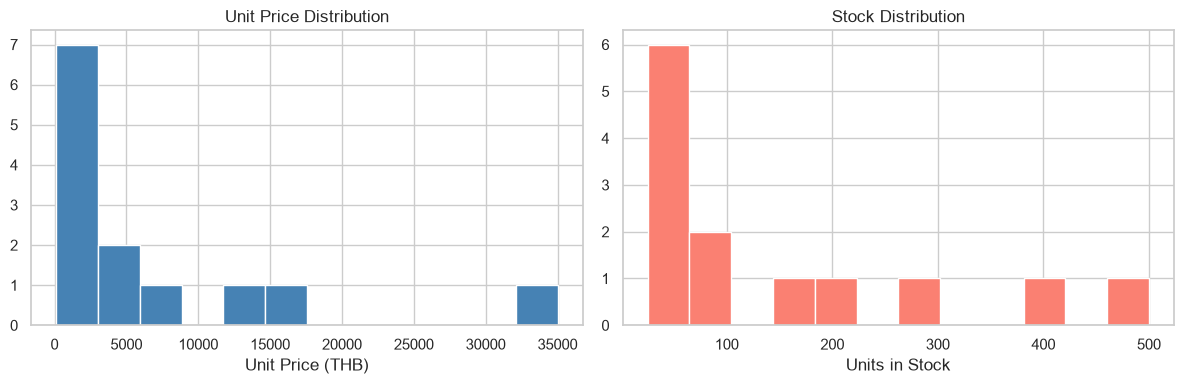

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['unit_price'].hist(bins=12, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Unit Price Distribution')
axes[0].set_xlabel('Unit Price (THB)')

df['stock'].hist(bins=12, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Stock Distribution')
axes[1].set_xlabel('Units in Stock')

plt.tight_layout()
plt.show()

How many products fall into each price tier?

In [7]:
df['price_tier'].value_counts().sort_index()

price_tier
budget     5
mid        5
premium    3
Name: count, dtype: int64

## 4. Products by Category

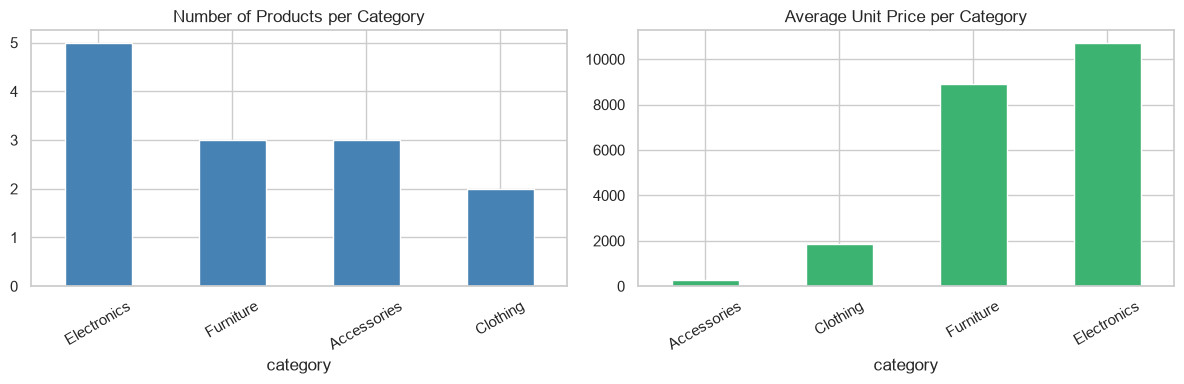

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Products per Category')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('category')['unit_price'].mean().sort_values().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Average Unit Price per Category')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Inventory Value

Where is the catalog's money tied up?

Inventory value by category:
category
Electronics    2650000
Furniture       924500
Clothing        413500
Accessories     307000
Name: stock_value, dtype: int64


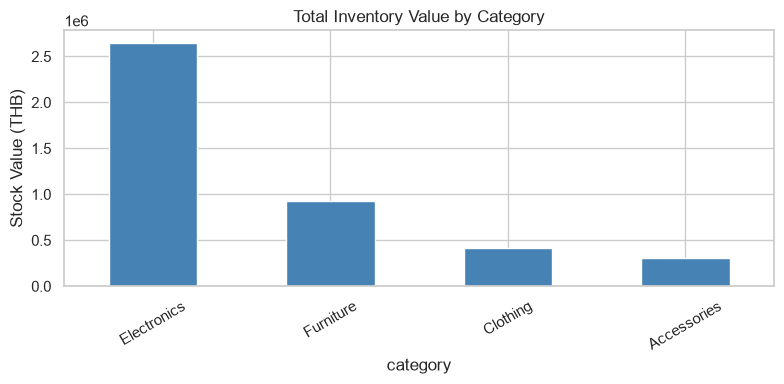

In [9]:
by_cat = df.groupby('category')['stock_value'].sum().sort_values(ascending=False)
print('Inventory value by category:')
print(by_cat)

by_cat.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title('Total Inventory Value by Category')
plt.ylabel('Stock Value (THB)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Inventory value split by category × supplier.

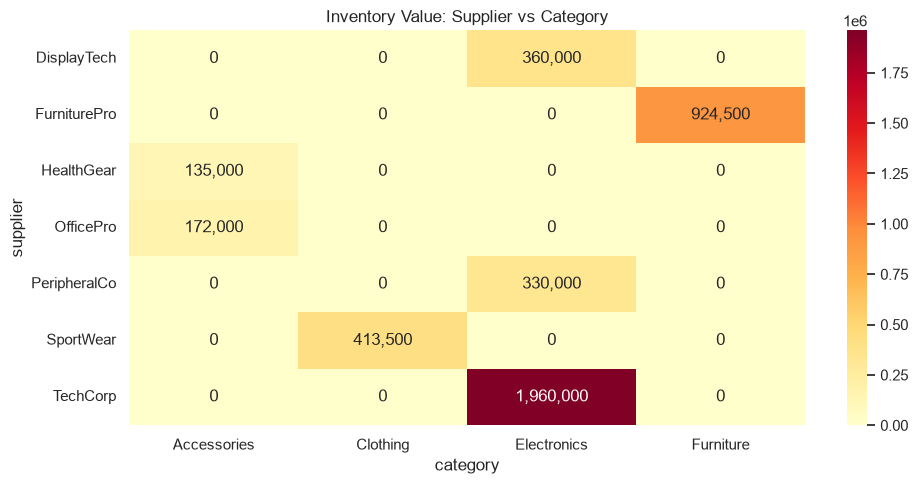

In [10]:
pivot = df.pivot_table(values='stock_value', index='supplier', columns='category', aggfunc='sum', fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd')
plt.title('Inventory Value: Supplier vs Category')
plt.tight_layout()
plt.show()

## 6. Suppliers

In [11]:
by_supplier = df.groupby('supplier').agg(
    products=('id', 'count'),
    total_stock=('stock', 'sum'),
    stock_value=('stock_value', 'sum'),
).sort_values('stock_value', ascending=False)
by_supplier

,products,total_stock,stock_value
supplier,,,
TechCorp,2,110,1960000
FurniturePro,3,100,924500
SportWear,2,250,413500
DisplayTech,1,30,360000
PeripheralCo,2,280,330000
OfficePro,2,900,172000
HealthGear,1,300,135000


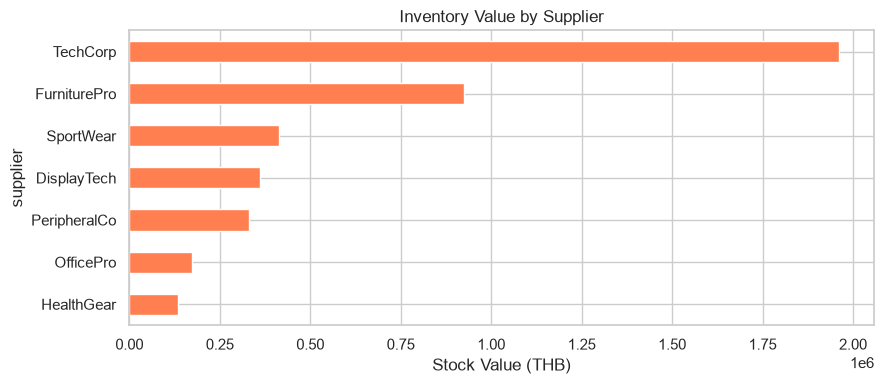

In [12]:
by_supplier['stock_value'].plot(kind='barh', figsize=(9, 4), color='coral')
plt.title('Inventory Value by Supplier')
plt.xlabel('Stock Value (THB)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Price vs Stock

Do expensive products tend to be stocked in smaller quantities?

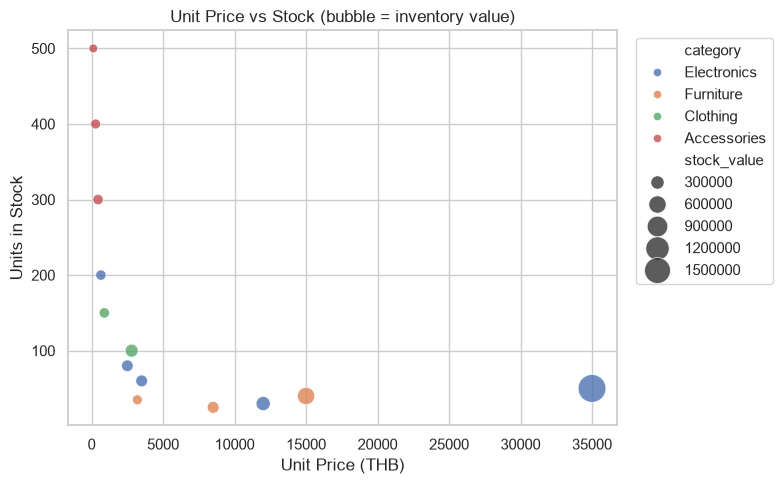

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='unit_price', y='stock', hue='category', size='stock_value',
                sizes=(40, 400), alpha=0.8)
plt.title('Unit Price vs Stock (bubble = inventory value)')
plt.xlabel('Unit Price (THB)')
plt.ylabel('Units in Stock')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
print('Price vs stock correlation:', round(df['unit_price'].corr(df['stock']), 3))

Price vs stock correlation: -0.469


## 8. Key Findings

In [15]:
total_value = df['stock_value'].sum()
top_cat = by_cat.idxmax()
top_supplier = by_supplier['stock_value'].idxmax()
top_product = df.loc[df['stock_value'].idxmax()]
most_stocked = df.loc[df['stock'].idxmax()]

print('=' * 52)
print('KEY FINDINGS — Product Catalog')
print('=' * 52)
print(f"Products              : {len(df)} across {df['category'].nunique()} categories")
print(f"Total inventory value : {total_value:>14,.0f} THB")
print(f"Top category (value)  : {top_cat} ({by_cat[top_cat] / total_value * 100:.1f}%)")
print(f"Top supplier (value)  : {top_supplier}")
print(f"Most valuable product : {top_product['name']} ({top_product['stock_value']:,.0f} THB)")
print(f"Most stocked product  : {most_stocked['name']} ({most_stocked['stock']} units)")

KEY FINDINGS — Product Catalog
Products              : 13 across 4 categories
Total inventory value :      4,295,000 THB
Top category (value)  : Electronics (61.7%)
Top supplier (value)  : TechCorp
Most valuable product : Laptop Pro (1,750,000 THB)
Most stocked product  : Notebook (500 units)


---
## Try It Yourself

1. Which **category** has the highest *average* stock value per product?
2. Which products are **premium** priced but **low** in stock (under 40 units)?
3. If you reorder every product below 30 units up to 50, what's the added inventory value?
4. Which supplier offers the widest **price range**?

**Hint:** combine `groupby`, boolean filtering, and the `stock_value` column.